# 06 — El informe

Este notebook no calcula nada. Lee lo que los notebooks 00 a 05 dejaron en
`resultados/` y lo compone en `informe/Informe_MIAX_Agente_10K.pdf`.

## Por qué el informe se genera por código

Un informe escrito a mano se separa de los datos en cuanto se vuelve a
ejecutar una evaluación: la tabla del documento dice una cosa, el CSV dice
otra, y no hay forma de saber cuál es la buena sin rehacer el trabajo. Es un
problema real en este proyecto, donde la tabla se ha regenerado varias veces
mientras se ajustaban los evaluadores.

Generándolo por código, el PDF **no puede** estar desactualizado: o los
ficheros de resultados están y las cifras son las últimas medidas, o no
están y el informe lo dice en su sitio en lugar de callárselo.

Eso obliga a una disciplina en la redacción: la prosa describe el método, la
interpretación y los límites, y **no contiene cifras escritas a mano**. Las
comparaciones que sí dependen de valores concretos —cuánto mejoró el final
respecto al baseline, cuántas veces más caro es— las calcula el código
leyendo los CSV.

## Por qué ReportLab y no LaTeX

Tres razones, en orden de peso:

1. **No añade dependencias del sistema.** LaTeX exige una distribución de
   varios gigabytes; `pandoc` y `wkhtmltopdf` son binarios externos. El
   enunciado pide que el proyecto se ejecute en un clon limpio, y
   `pip install reportlab` es todo lo que hace falta.
2. **Las tablas se construyen desde los `DataFrame`**, sin un paso intermedio
   de serializar a texto y volver a parsear, que es donde se pierden el
   formato de las cifras y el resaltado.
3. **El resaltado condicional es trivial**: marcar la mejor celda de cada
   columna es un bucle sobre un `TableStyle`, no una extensión de Markdown.

Los gráficos los hace Matplotlib y se incrustan como PNG. Se guardan también
sueltos en `informe/figuras/` por si hacen falta para las diapositivas.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import pandas as pd

from agente import config, informe

pd.set_option("display.width", 220)

datos = informe.recopilar()

print("Qué hay en resultados/ y qué falta:\n")
ESPERADOS = {
    "retrieval": "04 · las ocho configuraciones de retrieval",
    "retrieval_por_conjunto": "04 · las tres obligatorias por conjunto",
    "comparativa": "05 · la tabla baseline/filtros/final",
    "ausencias": "05 · las preguntas cuya respuesta es «no está»",
    "holdout": "07 · el ensayo con hold-out simulado",
}
for clave, descripcion in ESPERADOS.items():
    tabla = datos.get(clave)
    estado = f"{len(tabla):3d} filas" if tabla is not None else "   FALTA"
    print(f"  {estado}  {descripcion}")

print(f"\nCorpus: {datos['corpus']}")
print(f"Golden sets: oficial {len(datos['golden_oficial'])} · "
      f"propio {len(datos['golden_propio'])} · "
      f"ausencias {len(datos['golden_ausencias'])}")

Qué hay en resultados/ y qué falta:

   14 filas  04 · las ocho configuraciones de retrieval
    5 filas  04 · las tres obligatorias por conjunto
    6 filas  05 · la tabla baseline/filtros/final
    3 filas  05 · las preguntas cuya respuesta es «no está»
   10 filas  07 · el ensayo con hold-out simulado

Corpus: {'secciones': 48, 'chunks': 1749, 'tokens': 649119, 'hechos_xbrl': 137, 'conceptos': 14, 'emisores': 6}
Golden sets: oficial 20 · propio 20 · ausencias 7


## Antes de generar: los nombres

Lo único del informe que no se puede deducir de los datos son los tres
nombres de la portada. Están en la constante `INTEGRANTES`, al principio de
`agente/informe.py`.

Mientras conserven el marcador, la portada los imprime **en rojo** y con una
advertencia visible, y el generador avisa por consola al terminar. Es
deliberado: un PDF que se entrega con «NOMBRE Y APELLIDOS 1» en la portada es
un fallo caro y silencioso, y la forma de que no pase es que no se pueda
pasar por alto.

In [2]:
print("Integrantes configurados:")
for nombre in informe.INTEGRANTES:
    marca = "  <-- SIN RELLENAR" if informe.MARCADOR in nombre else ""
    print(f"  · {nombre}{marca}")

if any(informe.MARCADOR in n for n in informe.INTEGRANTES):
    print(f"\nEdita INTEGRANTES en {Path('agente/informe.py')} y vuelve a "
          f"ejecutar esta celda y la siguiente.")

Integrantes configurados:
  · NOMBRE Y APELLIDOS 1  <-- SIN RELLENAR
  · NOMBRE Y APELLIDOS 2  <-- SIN RELLENAR
  · NOMBRE Y APELLIDOS 3  <-- SIN RELLENAR

Edita INTEGRANTES en agente\informe.py y vuelve a ejecutar esta celda y la siguiente.


## Los gráficos, por separado

Se generan aquí antes de componer el PDF para poder verlos en el notebook.
`agente/informe.py` los vuelve a generar al construir el documento, así que
esta celda es solo para inspección: si un gráfico sale mal, es mejor verlo
aquí que buscarlo dentro de un PDF de veinte páginas.

Tres gráficos, y cada uno responde a una pregunta distinta:

1. **Recall por configuración de retrieval.** Barras horizontales porque las
   etiquetas son frases; en vertical habría que girarlas o abreviarlas.
2. **Calidad contra coste de los tres sistemas.** En dos paneles y no en dos
   ejes del mismo: superponer un porcentaje y un precio con dos escalas
   invita a leer cruces entre las líneas que no significan nada.
3. **Acierto por familia.** Promediado sobre los dos conjuntos, porque
   separarlo además por conjunto dejaría barras de tres preguntas.

[recall por configuración de retrieval] -> C:\Users\jdmar\Desktop\Taller NLP\informe\figuras\recall_retrieval.png


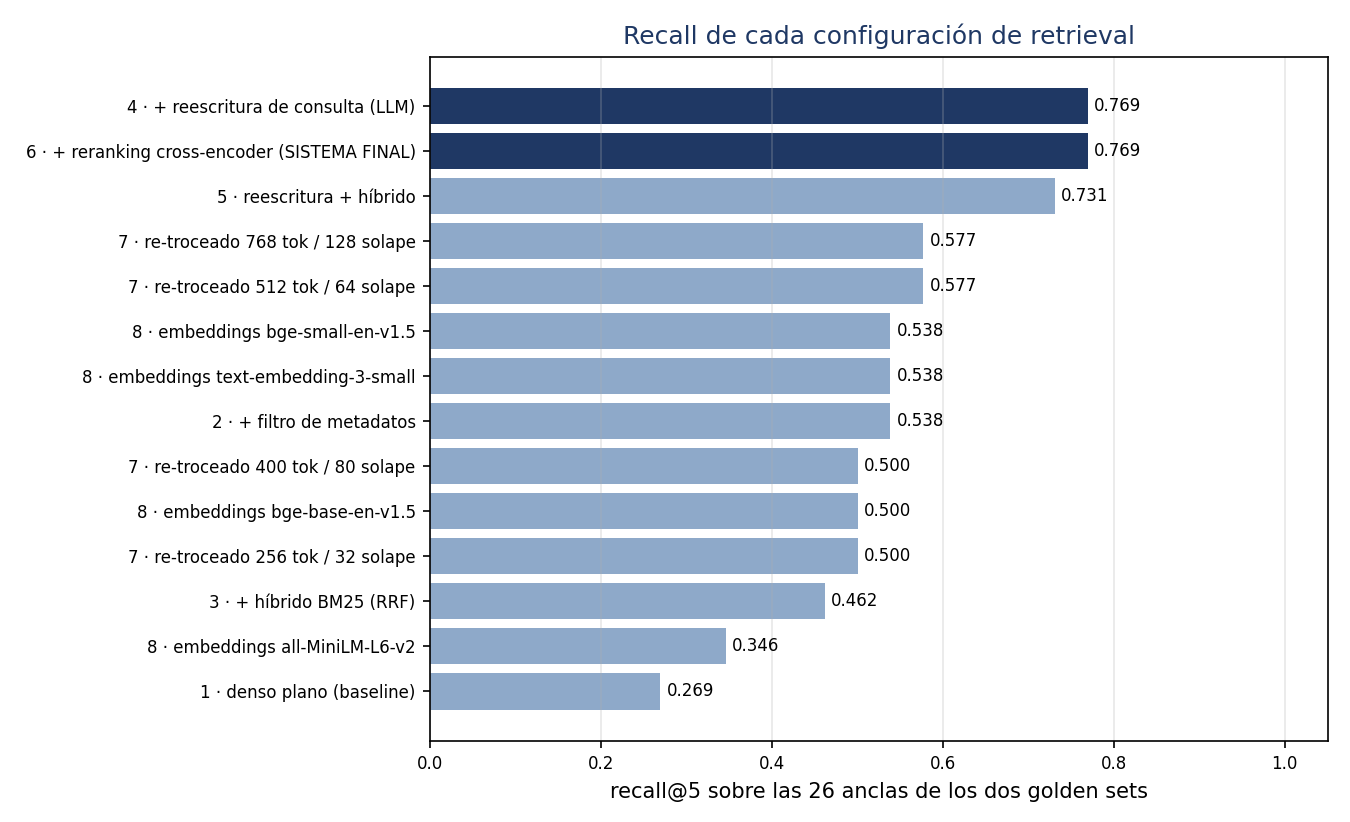

[calidad y coste de los tres sistemas] -> C:\Users\jdmar\Desktop\Taller NLP\informe\figuras\sistemas.png


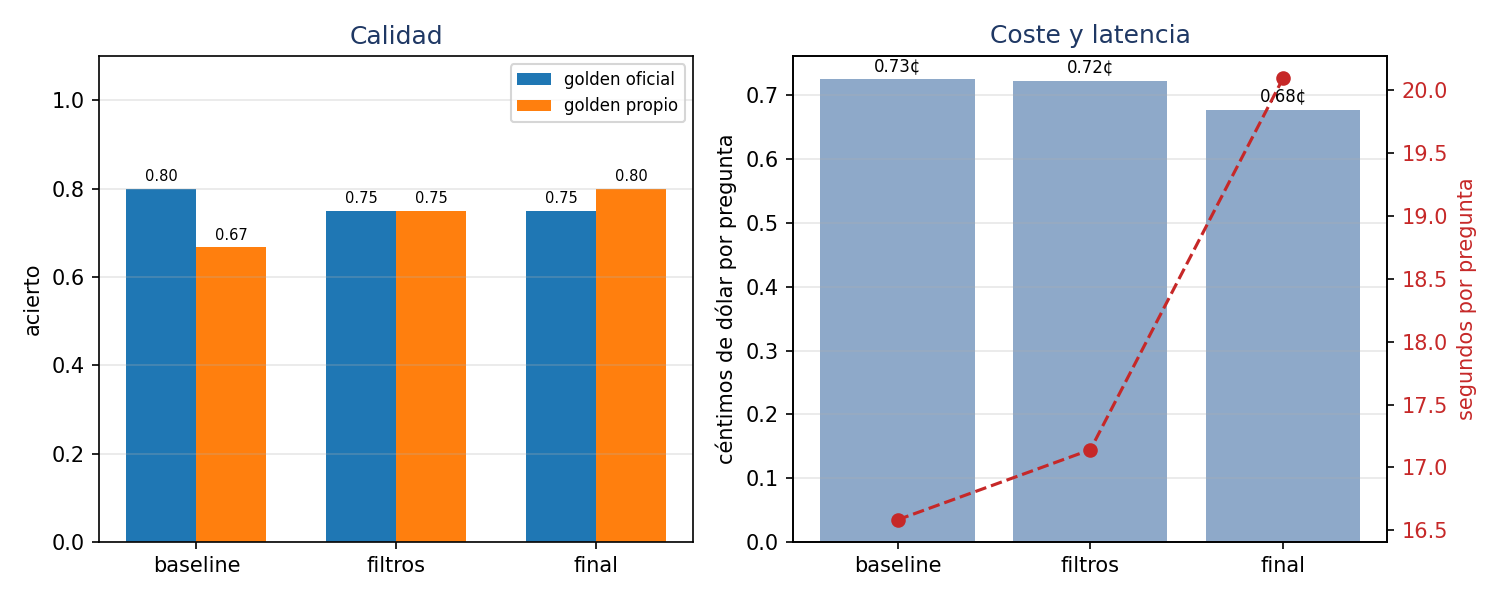

[acierto por familia de pregunta] -> C:\Users\jdmar\Desktop\Taller NLP\informe\figuras\familias.png


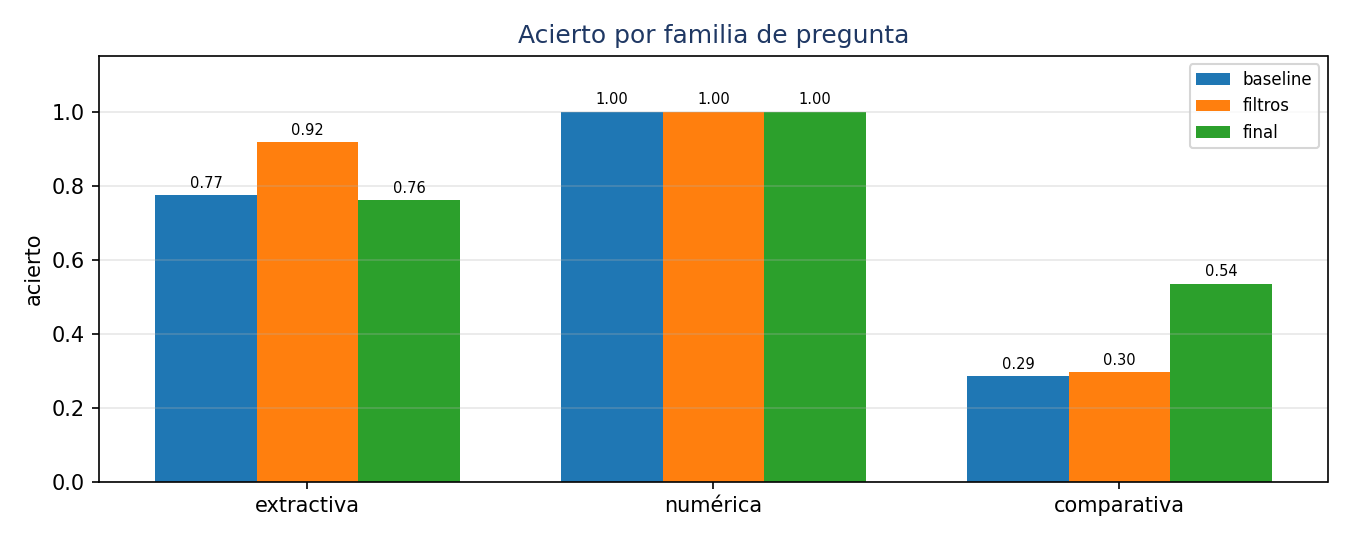

In [3]:
from IPython.display import Image, display

for nombre, funcion in [
    ("recall por configuración de retrieval", informe.grafico_recall),
    ("calidad y coste de los tres sistemas", informe.grafico_sistemas),
    ("acierto por familia de pregunta", informe.grafico_familias),
]:
    ruta = funcion(datos)
    if ruta is None:
        print(f"[{nombre}] sin datos todavía")
        continue
    print(f"[{nombre}] -> {ruta}")
    display(Image(filename=str(ruta), width=780))

## Composición del PDF

Once secciones, en el orden en que un lector necesita la información:

1. **Resumen ejecutivo** — los números que resumen el trabajo y cómo leerlos.
2. **Arquitectura y criterio de enrutado** — por qué un agente y no un RAG,
   las cuatro herramientas y los detalles de dominio que causan los fallos.
3. **Reconstrucción del corpus** — qué faltaba, cómo se reconstruyó y por qué
   la validación no puede ser el SHA-256.
4. **El golden set propio** — cómo se construyó y por qué las ausencias van
   aparte.
5. **Las mejoras de retrieval, medidas** — las ocho configuraciones, con el
   gráfico y la lectura de cada resultado.
6. **Guardrails** — el verificador contra XBRL y los dos topes de llamadas.
7. **Los tres evaluadores** — qué detecta cada uno y el cuarto que hizo falta.
8. **Baseline contra intermedio contra final** — la tabla, resaltada.
9. **Lo que se probó y no funcionó** — los resultados negativos, medidos.
10. **¿Generalizará a las diez preguntas ciegas?** — el argumento en los dos
    sentidos.
11. **Reproducibilidad y entrega** — el orden de ejecución y la configuración
    exacta con la que se midió.

El orden no es arbitrario: las secciones 2 a 7 explican **cómo** está hecho
el sistema, y solo después, en la 8, se enseña lo que consigue. Enseñar
primero la tabla y justificarla después invita a leer los números sin saber
qué significan las columnas.

In [4]:
ruta_pdf = informe.generar()

print(f"\n{ruta_pdf.resolve()}")
print(f"{ruta_pdf.stat().st_size / 1024:.0f} KB")

for figura in sorted(informe.DIR_FIGURAS.glob("*.png")):
    print(f"  figura: {figura.name}  {figura.stat().st_size / 1024:.0f} KB")

Informe escrito en C:\Users\jdmar\Desktop\Taller NLP\informe\Informe_MIAX_Agente_10K.pdf  (285 KB)
AVISO: la portada sigue con los marcadores de nombre. Rellena INTEGRANTES en agente/informe.py.

C:\Users\jdmar\Desktop\Taller NLP\informe\Informe_MIAX_Agente_10K.pdf
285 KB
  figura: familias.png  31 KB
  figura: recall_retrieval.png  87 KB
  figura: sistemas.png  65 KB


## Comprobación final antes de entregar

La lista de lo que tiene que estar, comprobada por código en lugar de a ojo.
No cubre la calidad del contenido —eso no lo puede comprobar un `assert`—,
sino que no falte ninguna pieza del entregable, que es el fallo tonto que
arruina una entrega por lo demás correcta.

In [5]:
COMPROBACIONES = [
    ("El PDF existe y no está vacío",
     ruta_pdf.is_file() and ruta_pdf.stat().st_size > 50_000),
    ("Los nombres de la portada están rellenos",
     not any(informe.MARCADOR in n for n in informe.INTEGRANTES)),
    ("Hay tabla de retrieval (notebook 04)", datos.get("retrieval") is not None),
    ("Hay tabla comparativa (notebook 05)", datos.get("comparativa") is not None),
    ("Hay resultados de ausencias", datos.get("ausencias") is not None),
    ("El golden set propio tiene 20 preguntas",
     len(datos.get("golden_propio") or []) == 20),
    ("El golden set propio tiene 6 comparativas o más",
     sum(p.get("familia") == "comparativa"
         for p in datos.get("golden_propio") or []) >= 6),
    ("api_key.txt está en .gitignore",
     "api_key.txt" in Path(".gitignore").read_text(encoding="utf-8")),
    ("No hay ninguna clave escrita en el paquete",
     not any("sk-" in f.read_text(encoding="utf-8")
             for f in Path("agente").glob("*.py"))),
    ("requirements.txt fija versiones, no rangos",
     Path("requirements.txt").read_text(encoding="utf-8").count("==") >= 8),
    ("responder() y evaluar() son importables desde agente",
     all(hasattr(__import__("agente.interfaz", fromlist=["x"]), n)
         for n in ("responder", "evaluar"))),
]

fallan = []
for descripcion, condicion in COMPROBACIONES:
    print(f"  {'OK ' if condicion else 'NO '} {descripcion}")
    if not condicion:
        fallan.append(descripcion)

if fallan:
    print(f"\nQuedan {len(fallan)} cosas por resolver antes de entregar.")
else:
    print("\nTodo en su sitio.")

  OK  El PDF existe y no está vacío
  NO  Los nombres de la portada están rellenos
  OK  Hay tabla de retrieval (notebook 04)
  OK  Hay tabla comparativa (notebook 05)
  OK  Hay resultados de ausencias
  OK  El golden set propio tiene 20 preguntas
  OK  El golden set propio tiene 6 comparativas o más
  OK  api_key.txt está en .gitignore
  OK  No hay ninguna clave escrita en el paquete
  OK  requirements.txt fija versiones, no rangos
  OK  responder() y evaluar() son importables desde agente

Quedan 1 cosas por resolver antes de entregar.


## Qué queda fuera del PDF, y dónde está

El informe no incluye los resultados crudos: sería ilegible y no aportaría
nada que no esté ya resumido. Lo que sí hay que saber es **dónde** están,
porque es lo que permite auditar cualquier cifra del documento:

| Fichero | Qué contiene |
| --- | --- |
| `resultados/eval_<conjunto>_<sistema>.csv` | Una fila por pregunta, con los cuatro evaluadores, coste, latencia y lo que respondió |
| `resultados/eval_<conjunto>_<sistema>.jsonl` | La **trayectoria completa** de cada invocación: qué herramientas llamó, con qué argumentos y qué devolvieron |
| `resultados/retrieval_experimentos.csv` | Las ocho configuraciones con su `recall@5`, posición mediana del ancla, latencia y coste |
| `resultados/tabla_comparativa.csv` | La tabla del capítulo 8, en crudo |
| `informe/figuras/*.png` | Los tres gráficos, sueltos |

El `.jsonl` con la trayectoria es el que más veces se acaba abriendo. Una
tabla de aciertos dice qué falló y no dice por qué; sin el porqué no se puede
arreglar nada, y volver a ejecutar la evaluación para averiguarlo cuesta
dinero y media hora.